# Exploratory Data Analysis — Semiconductor Yield Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

In [2]:
df = pd.read_csv("../data/yield_data.csv")
df.head()

,temperature_C,pressure_mTorr,gas_flow_sccm,rf_power_W,deposition_time_s,chamber_humidity,yield_percent
0,274.908024,362.931283,51.980724,716.975214,74.395171,37.934722,87.027331
1,390.142861,346.768672,50.148572,520.813866,64.298707,25.689067,87.719734
2,346.398788,56.919557,262.518557,150.136206,181.162753,27.581553,89.833884
3,319.731697,462.060478,63.182167,926.659136,491.633312,30.840268,62.432998
4,231.203728,288.551379,488.539649,982.296220,548.563735,32.219200,83.750524


## 1. Distribution Plots — Features

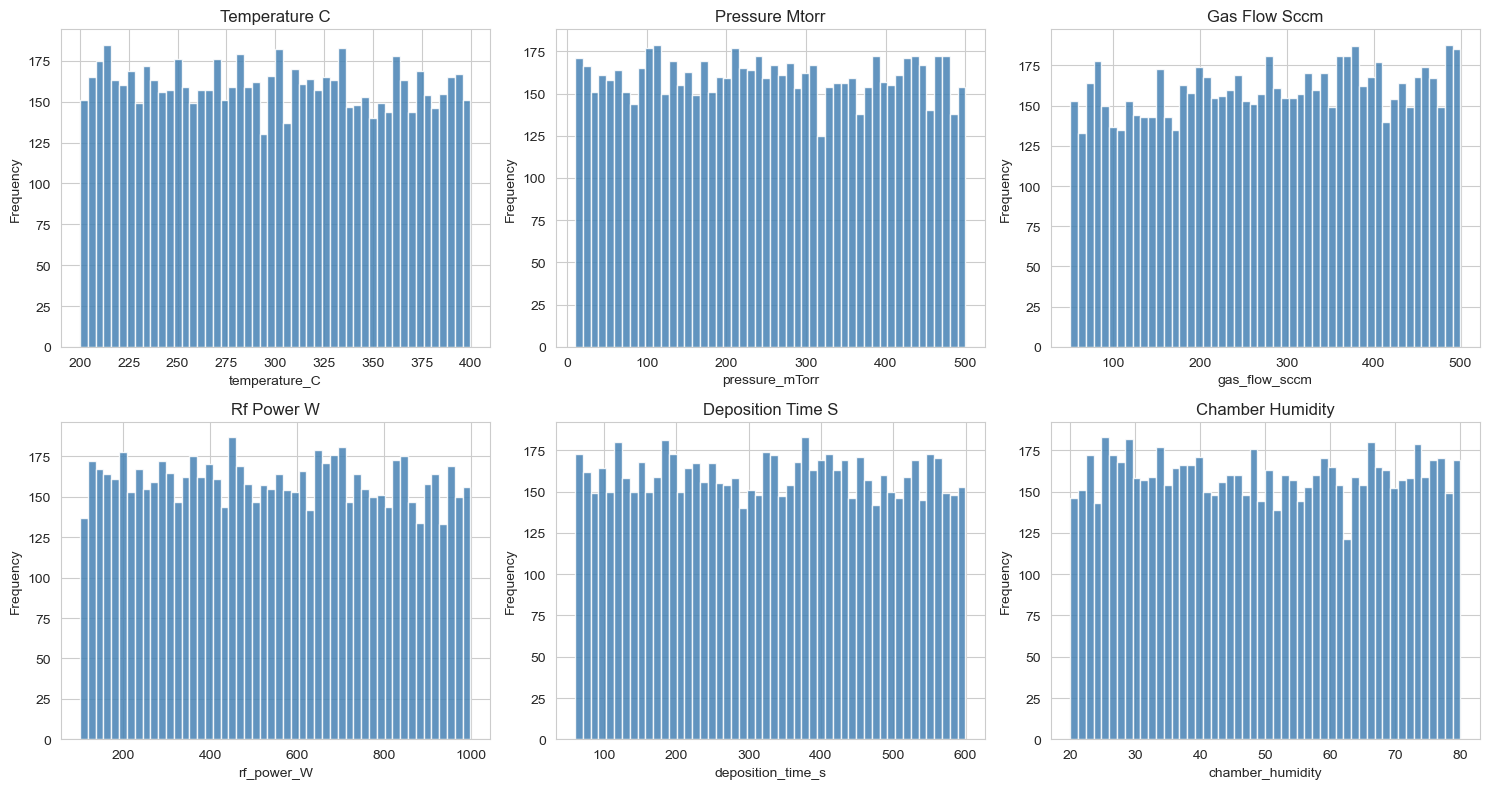

In [3]:
features = ["temperature_C", "pressure_mTorr", "gas_flow_sccm", "rf_power_W", "deposition_time_s", "chamber_humidity"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].hist(df[feat], bins=50, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].set_title(feat.replace("_", " ").title())
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 2. Distribution Plot — Target

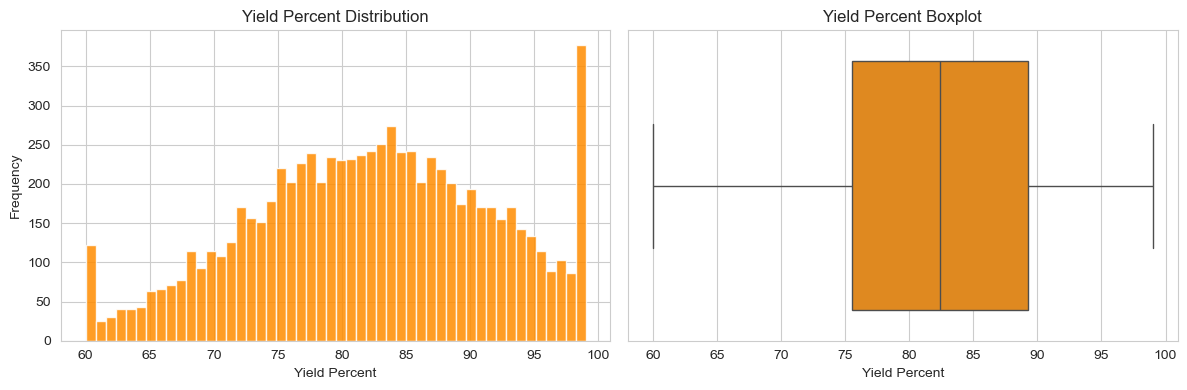

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df["yield_percent"], bins=50, color="darkorange", edgecolor="white", alpha=0.85)
ax[0].set_title("Yield Percent Distribution")
ax[0].set_xlabel("Yield Percent")
ax[0].set_ylabel("Frequency")

sns.boxplot(x=df["yield_percent"], color="darkorange", ax=ax[1])
ax[1].set_title("Yield Percent Boxplot")
ax[1].set_xlabel("Yield Percent")

plt.tight_layout()
plt.show()

## 3. Correlation Heatmap

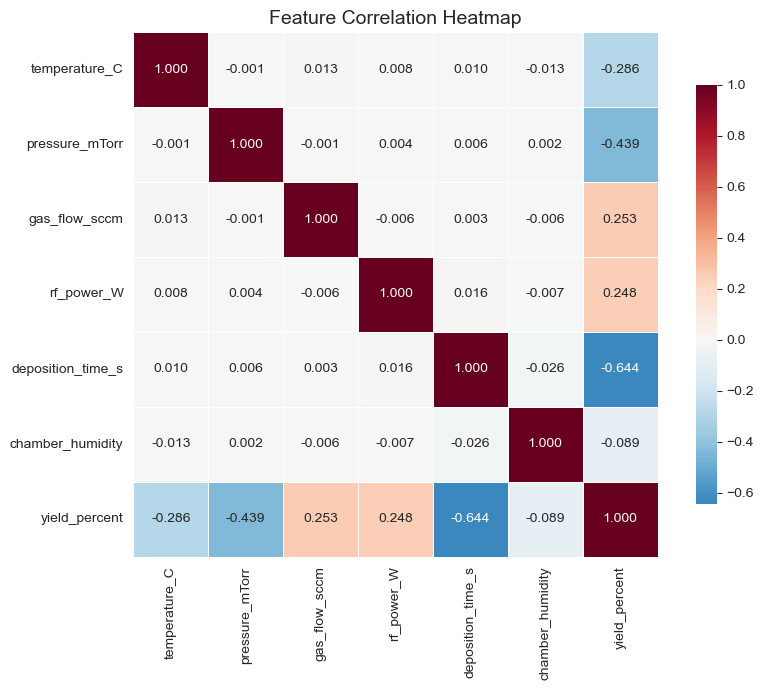

Exported to results/correlation_matrix.csv


In [5]:
corr_matrix = df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

corr_matrix.to_csv("../results/correlation_matrix.csv")
print("Exported to results/correlation_matrix.csv")

## 4. Scatter Plots — Each Feature vs Yield

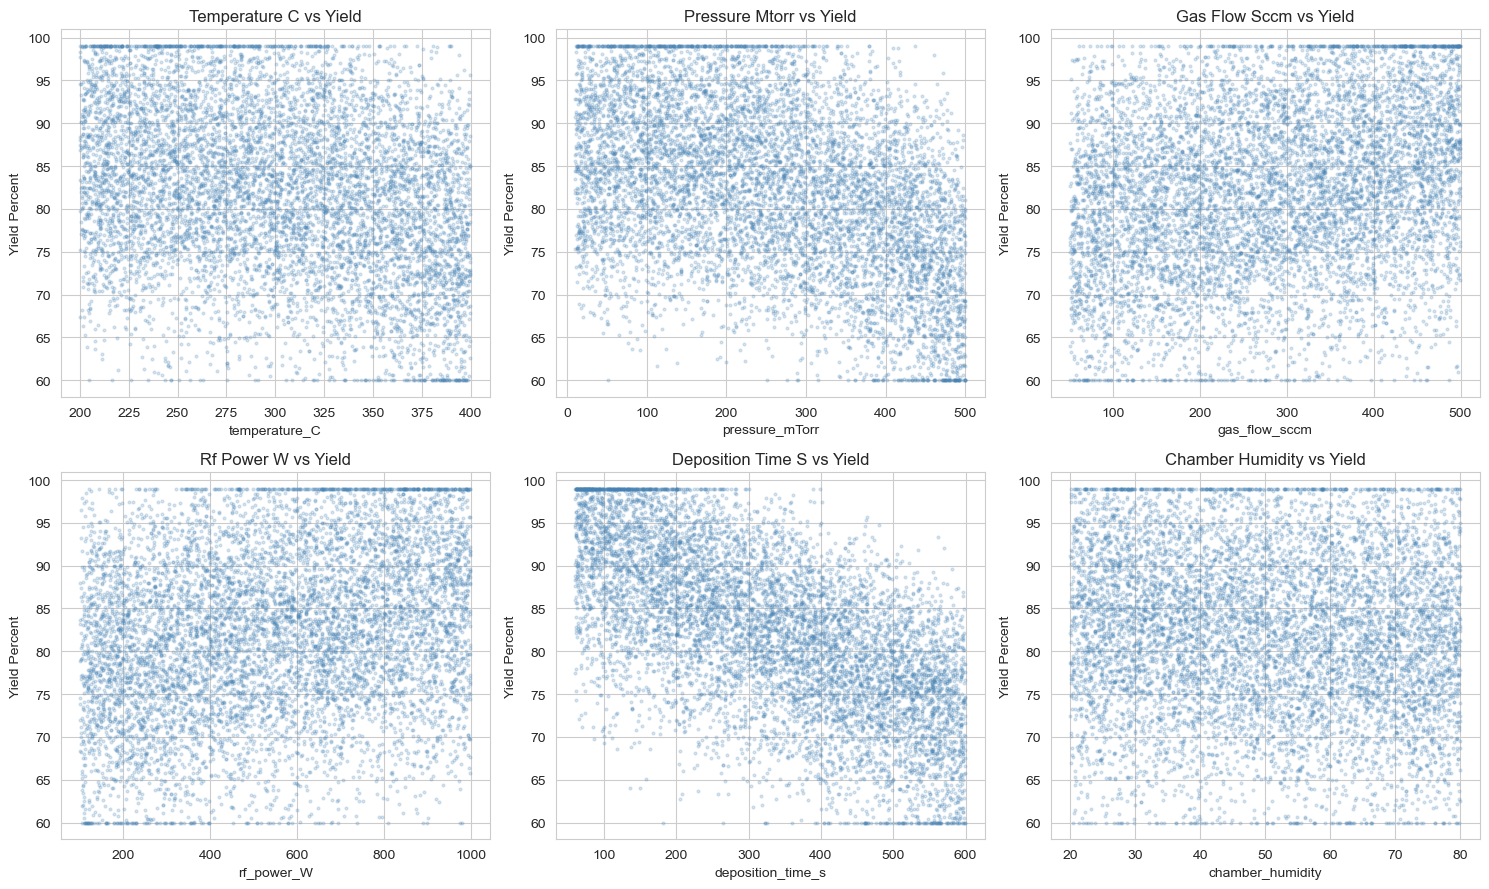

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].scatter(df[feat], df["yield_percent"], alpha=0.2, s=4, color="steelblue")
    axes[i].set_title(f"{feat.replace('_', ' ').title()} vs Yield")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Yield Percent")

plt.tight_layout()
plt.show()

## 5. Pairplot

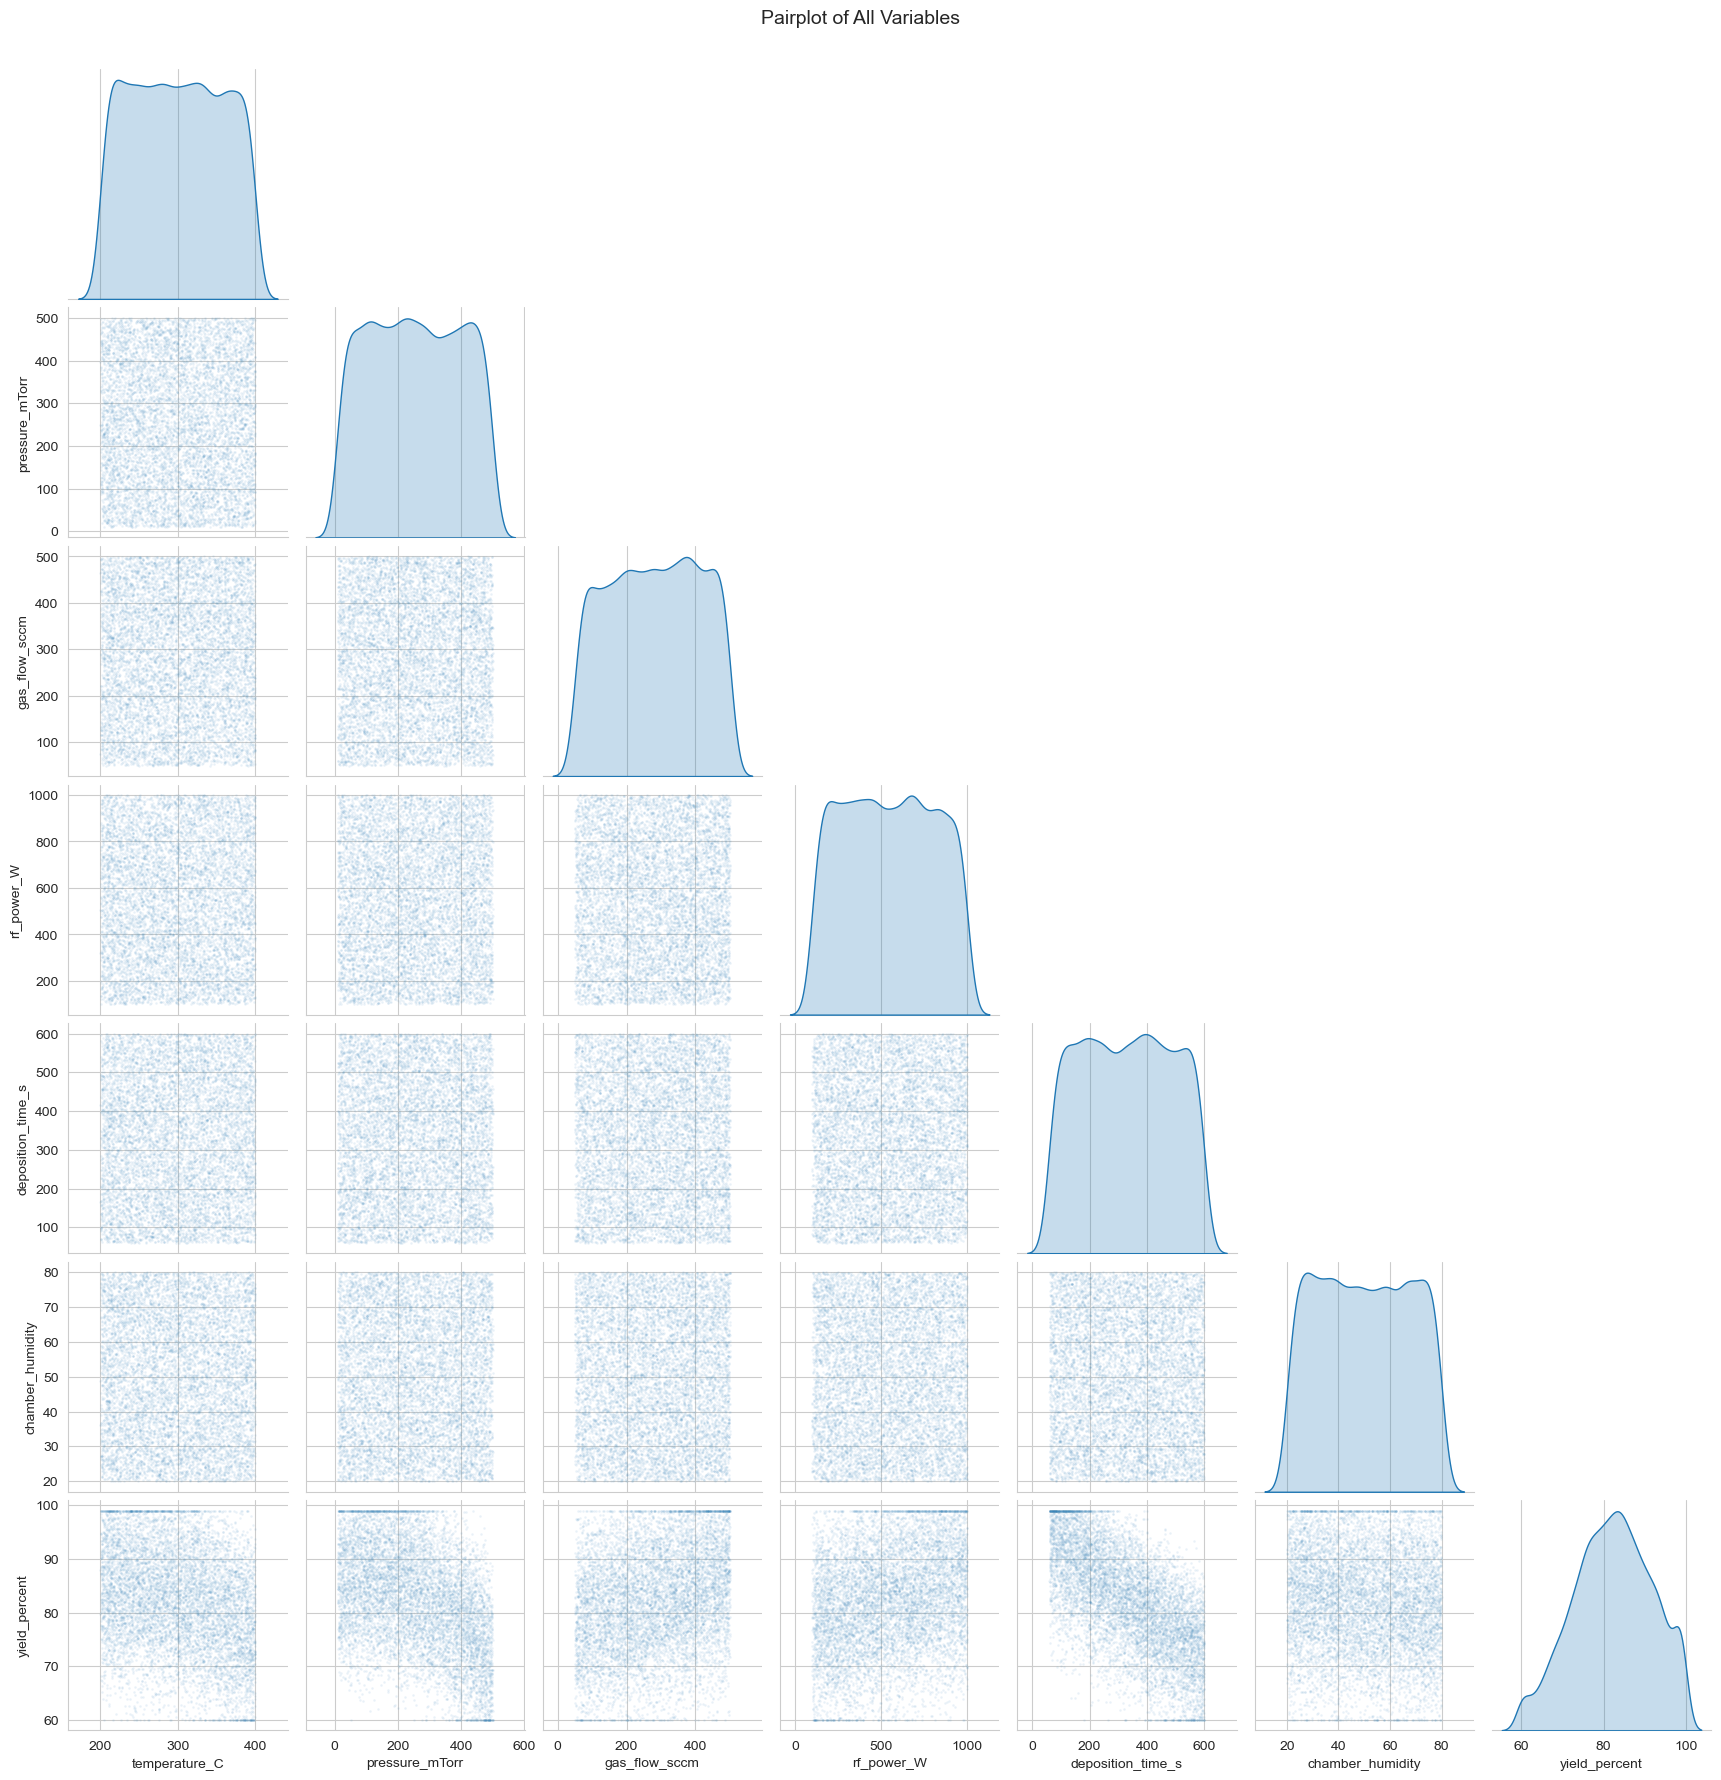

In [7]:
pp = sns.pairplot(df, diag_kind="kde", plot_kws={"alpha": 0.1, "s": 3},
                  corner=True)
pp.fig.suptitle("Pairplot of All Variables", y=1.02, fontsize=14)
plt.show()

## 6. Top 3 Features Most Correlated with Yield

Below we rank features by the absolute value of their Pearson correlation with `yield_percent`.

Top features by |correlation| with yield:
deposition_time_s    0.644100
pressure_mTorr       0.438950
temperature_C        0.285667
gas_flow_sccm        0.253212
rf_power_W           0.247748
chamber_humidity     0.089008
Name: yield_percent, dtype: float64


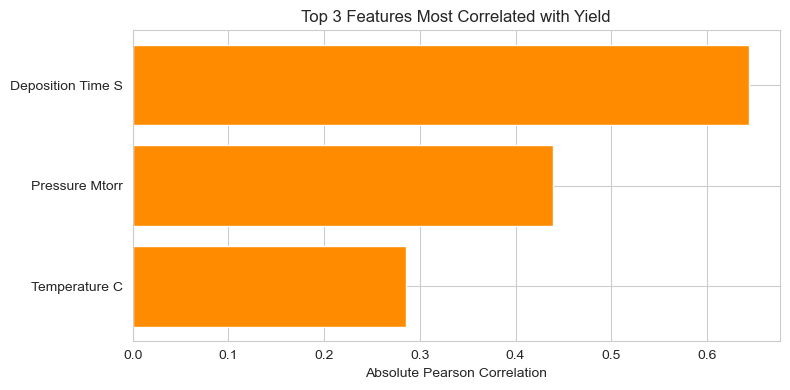

In [8]:
yield_corrs = corr_matrix["yield_percent"].drop("yield_percent").abs().sort_values(ascending=False)
print("Top features by |correlation| with yield:")
print(yield_corrs)

top3 = yield_corrs.head(3)
plt.figure(figsize=(8, 4))
bars = plt.barh(top3.index[::-1].str.replace("_", " ").str.title(), top3.values[::-1], color="darkorange")
plt.xlabel("Absolute Pearson Correlation")
plt.title("Top 3 Features Most Correlated with Yield")
plt.tight_layout()
plt.show()

The top 3 features most correlated with `yield_percent` are:

1. **Deposition Time** — strongest negative correlation (r ≈ –0.64); longer deposition sharply reduces yield, amplified by its interaction with temperature in the data generation.
2. **Pressure** — strong negative correlation (r ≈ –0.44); higher chamber pressure is associated with lower yield.
3. **Temperature** — moderate negative correlation (r ≈ –0.29); higher temperature reduces yield, with visible non-linear curvature in the scatter plot.